Netflix is known for its work in data science, Al, and ML, particularly for building strong
recommendation models and algorithms that understand customer behavior and patterns.
Suppose you are working in a data-driven job role, and you have a dataset of more than
9,000 movies. You need to solve the following questions to help the company make
informed business decisions accordingly.
1) What is the most frequent genre of movies released on Netflix?
2) Which has highest votes in Vote_Average column?
3) What movie got the highest popularity? what's its genre?
4) What movie got the lowest popularity? what's its genre?
5) Which year has the most filmmed movies?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("mymoviedb.csv",lineterminator= "\n")

In [3]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   object 
 1   Title              9827 non-null   object 
 2   Overview           9827 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   object 
 7   Genre              9827 non-null   object 
 8   Poster_Url         9827 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 691.1+ KB


In [5]:
df["Genre"].head()

0    Action, Adventure, Science Fiction
1              Crime, Mystery, Thriller
2                              Thriller
3    Animation, Comedy, Family, Fantasy
4      Action, Adventure, Thriller, War
Name: Genre, dtype: object

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe()

,Popularity,Vote_Count,Vote_Average
count,9827.000000,9827.000000,9827.000000
mean,40.326088,1392.805536,6.439534
std,108.873998,2611.206907,1.129759
min,13.354000,0.000000,0.000000
25%,16.128500,146.000000,5.900000
50%,21.199000,444.000000,6.500000
75%,35.191500,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000


 This is what I have found out from above :
 This df consists of 9827 rows and 9 columns.
 Release_Date, Title, Overview, Popularity, Vote_Count, Vote_Average, Original_Language	Genre, Poster_Url are the columns.
 There are 0 null values and no duplicate data.
 The Release_Date is in object type which should be changed to date and time.
 The Genre contains multiple values(Name of genre).That should be sepreaded by , (comma and whitespace).
 No longer need of 3 columns i.e.Overview, Original_Language, Poster_Url. 
 
 
 
 
 

In [8]:
df["Release_Date"]=pd.to_datetime(df["Release_Date"])


In [9]:
df["Release_Date"]

0      2021-12-15
1      2022-03-01
2      2022-02-25
3      2021-11-24
4      2021-12-22
          ...    
9822   1973-10-15
9823   2020-10-01
9824   2016-05-06
9825   2021-03-31
9826   1984-09-23
Name: Release_Date, Length: 9827, dtype: datetime64[ns]

In [10]:
df["Release_Date"].dtypes

dtype('<M8[ns]')

In [11]:
df["Release_Date"]=(df["Release_Date"].dt.year)    #we only need year not month and day

In [12]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [13]:
cols=["Overview","Original_Language","Poster_Url"]

In [14]:
df.drop(cols,axis=1,inplace=True)

In [15]:
df

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,6.3,Thriller
3,2021,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War"
...,...,...,...,...,...,...
9822,1973,Badlands,13.357,896,7.6,"Drama, Crime"
9823,2020,Violent Delights,13.356,8,3.5,Horror
9824,2016,The Offering,13.355,94,5.0,"Mystery, Thriller, Horror"
9825,2021,The United States vs. Billie Holiday,13.354,152,6.7,"Music, Drama, History"


# Vote_Average to 4 label i.e popular,average,below average and not popoular and assigning to new column

In [16]:
# Creating a function

In [17]:
def categorized_column(df,col,labels):
    edges=[df[col].describe()["min"],
    df[col].describe()["25%"],
    df[col].describe()["50%"],
    df[col].describe()["75%"],
    df[col].describe()["max"]]


    df[col]=pd.cut(df[col],edges,labels=labels,duplicates="drop")
    return df

In [18]:
labels=["Not_Popular","Below_Avg","Avg","Popular"]
categorized_column(df,"Vote_Average",labels)
df["Vote_Average"].unique()

['Popular', 'Below_Avg', 'Avg', 'Not_Popular', NaN]
Categories (4, object): ['Not_Popular' < 'Below_Avg' < 'Avg' < 'Popular']

In [19]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,Popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,Popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,Below_Avg,Thriller
3,2021,Encanto,2402.201,5076,Popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,Avg,"Action, Adventure, Thriller, War"


In [20]:
df["Vote_Average"].value_counts()

Vote_Average
Not_Popular    2467
Popular        2450
Avg            2412
Below_Avg      2398
Name: count, dtype: int64

In [21]:
df.dropna(inplace=True)
df.isna().sum()

Release_Date    0
Title           0
Popularity      0
Vote_Count      0
Vote_Average    0
Genre           0
dtype: int64

# Splitting genre into list

In [22]:
df["Genre"]=df["Genre"].str.split(", ")
df=df.explode("Genre").reset_index(drop=True)
df

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Science Fiction
3,2022,The Batman,3827.658,1151,Popular,Crime
4,2022,The Batman,3827.658,1151,Popular,Mystery
...,...,...,...,...,...,...
25547,2021,The United States vs. Billie Holiday,13.354,152,Avg,Drama
25548,2021,The United States vs. Billie Holiday,13.354,152,Avg,History
25549,1984,Threads,13.354,186,Popular,War
25550,1984,Threads,13.354,186,Popular,Drama


# Casting column into category

In [23]:
df["Genre"]=df["Genre"].astype("category")
df["Genre"].dtypes

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=object)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25552 entries, 0 to 25551
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Release_Date  25552 non-null  int32   
 1   Title         25552 non-null  object  
 2   Popularity    25552 non-null  float64 
 3   Vote_Count    25552 non-null  int64   
 4   Vote_Average  25552 non-null  category
 5   Genre         25552 non-null  category
dtypes: category(2), float64(1), int32(1), int64(1), object(1)
memory usage: 749.6+ KB


In [25]:
df

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Science Fiction
3,2022,The Batman,3827.658,1151,Popular,Crime
4,2022,The Batman,3827.658,1151,Popular,Mystery
...,...,...,...,...,...,...
25547,2021,The United States vs. Billie Holiday,13.354,152,Avg,Drama
25548,2021,The United States vs. Billie Holiday,13.354,152,Avg,History
25549,1984,Threads,13.354,186,Popular,War
25550,1984,Threads,13.354,186,Popular,Drama


In [26]:
df.nunique()

Release_Date     100
Title           9415
Popularity      8088
Vote_Count      3265
Vote_Average       4
Genre             19
dtype: int64

In [27]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Science Fiction
3,2022,The Batman,3827.658,1151,Popular,Crime
4,2022,The Batman,3827.658,1151,Popular,Mystery


In [28]:
sns.set_style("whitegrid")

# What is the most frequent genre of movies released on Netflix?

In [29]:
df["Genre"].describe()

count     25552
unique       19
top       Drama
freq       3715
Name: Genre, dtype: object

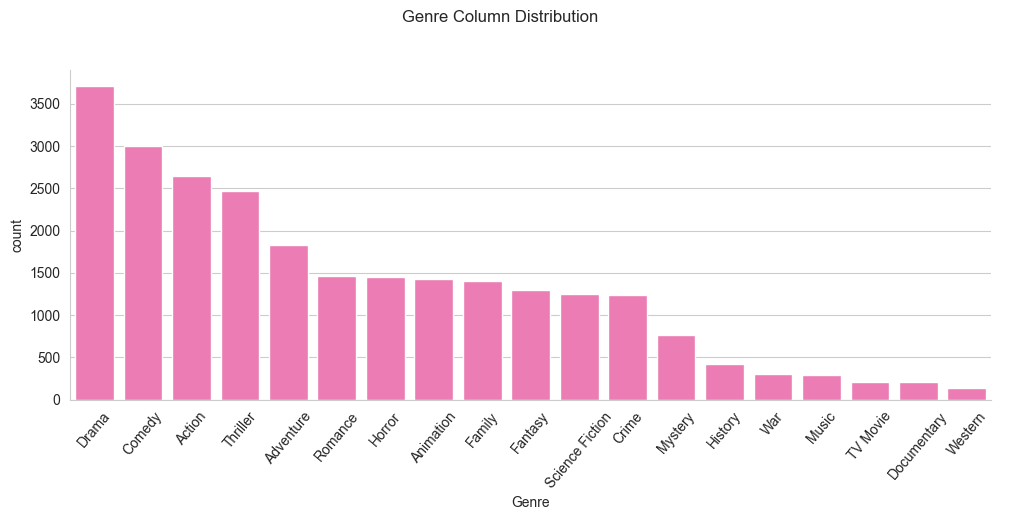

In [30]:
sns.catplot(
    x="Genre", data=df, kind="count",
    order=df["Genre"].value_counts().index,
    color="#FF69B4", height=5, aspect=2
).fig.suptitle("Genre Column Distribution", y=1.03)

plt.xticks(rotation=50)
plt.tight_layout()
plt.show()

# Ans: The most frequent genre of movies released is Drama. 

# Which has highest votes in Vote_Average column?

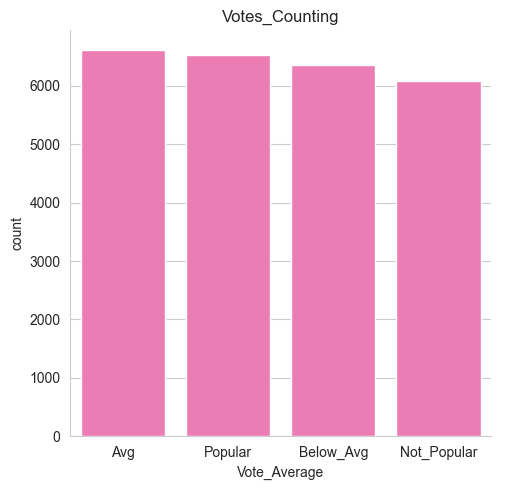

In [31]:
sns.catplot(x="Vote_Average",data=df,kind="count",order=df["Vote_Average"].value_counts().index,color="#FF69B4")
plt.title("Votes_Counting")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# Ans: Average Movie has highest votes in Vote_Average column.

# What movie got the highest popularity? what's its genre?

In [32]:
df = df.sort_values("Popularity", ascending=False)


In [33]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
2,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Science Fiction
0,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Adventure
4,2022,The Batman,3827.658,1151,Popular,Mystery
3,2022,The Batman,3827.658,1151,Popular,Crime


# Ans:The movie that  got the highest popularity is "Spider-Man: No Way Home"  its genre is Science Fiction,Action and Adventure

# What movie got the lowest popularity? what's its genre?

In [38]:
df.sort_values("Popularity",ascending=True).head(10)

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
25547,2021,The United States vs. Billie Holiday,13.354,152,Avg,Drama
25546,2021,The United States vs. Billie Holiday,13.354,152,Avg,Music
25549,1984,Threads,13.354,186,Popular,War
25548,2021,The United States vs. Billie Holiday,13.354,152,Avg,History
25551,1984,Threads,13.354,186,Popular,Science Fiction
25550,1984,Threads,13.354,186,Popular,Drama
25543,2016,The Offering,13.355,94,Not_Popular,Mystery
25545,2016,The Offering,13.355,94,Not_Popular,Horror
25544,2016,The Offering,13.355,94,Not_Popular,Thriller
25542,2020,Violent Delights,13.356,8,Not_Popular,Horror


# Ans: The movie That has lowest Popularity are The United States vs. Billie Holiday and Threads.the Genre of The United States vs. Billie Holiday	is Drama,Music,History and Genre of Threads is war,History,drama and Science Fiction

# Which year has the most filmmed movies?

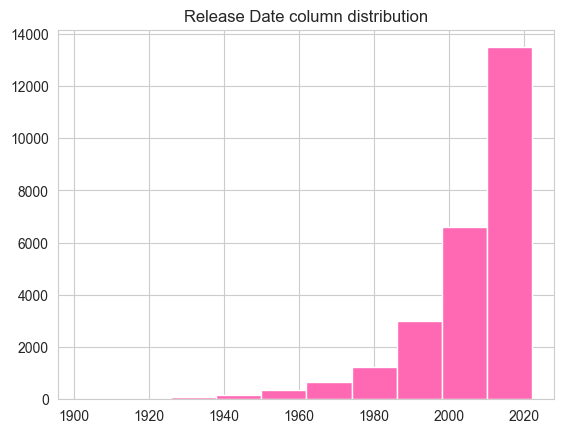

In [52]:
df["Release_Date"].hist(color="#FF69B4"),
plt.title("Release Date column distribution")
plt.show()

# Ans: 2020 was the year most movies were filmed.